In [ ]:
!pip install mediapipe opencv-python torch torchvision tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 9.0 MB/s eta 0:00:0

In [ ]:
from kagglehub import dataset_download

path = dataset_download("daudshah/video-dataset")
print("Dataset downloaded to:", path)

100%|██████████| 5.94G/5.94G [01:03<00:00, 100MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1


In [ ]:
import os
from pathlib import Path

root = Path(path) / "dataset-video-split"
for split in ["train", "test", "valid"]:
    print(split, "->", len(os.listdir(root / split)), "videos")

train -> 940 videos
test -> 200 videos
valid -> 194 videos


In [ ]:
from pathlib import Path
import shutil
import random
from collections import defaultdict

src_root = Path("/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/dataset-video-split")
output_base = Path("/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset")

data_splits = {
    'train': src_root / 'train',
    'test': src_root / 'test',
    'valid': src_root / 'valid'
}

def get_class_name(filename):
    for i, ch in enumerate(filename):
        if ch.isdigit() or ch == '_':
            return filename[:i]
    return filename.split('_')[0]

def balance_split(split_name, input_folder, output_folder):
    class_files = defaultdict(list)
    files = [f for f in input_folder.iterdir() if f.suffix == '.mp4']

    for f in files:
        cls = get_class_name(f.name)
        class_files[cls].append(f)

    min_count = min(len(v) for v in class_files.values())
    print(f"[{split_name}] Classes found: {list(class_files.keys())}")
    print(f"[{split_name}] Minimum class count: {min_count}")

    output_folder.mkdir(parents=True, exist_ok=True)

    for cls, files_list in class_files.items():
        sampled_files = random.sample(files_list, min_count)
        cls_folder = output_folder / cls
        cls_folder.mkdir(exist_ok=True)
        for file_path in sampled_files:
            shutil.copy2(file_path, cls_folder / file_path.name)
    print(f"[{split_name}] Balanced dataset created at {output_folder}\n")

def main():
    for split, folder in data_splits.items():
        out_folder = output_base / split
        balance_split(split, folder, out_folder)

if __name__ == "__main__":
    main()


[train] Classes found: ['Meet', 'RoadAccidents', 'Walking', 'Stealing', 'Robbery', 'Abuse', 'Normal', 'Burglary', 'Explosion', 'Standing', 'Arrest', 'Arson', 'Shooting', 'Vandalism', 'Assault', 'Shoplifting', 'Fighting', 'Clapping', 'Sitting']
[train] Minimum class count: 40
[train] Balanced dataset created at /root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/train

[test] Classes found: ['Normal', 'Clapping', 'Shoplifting', 'Walking', 'Sitting', 'Robbery', 'Standing', 'RoadAccidents', 'Meet', 'Burglary', 'Shooting', 'Arson', 'Stealing', 'Assault', 'Explosion', 'Fighting', 'Abuse', 'Vandalism', 'Arrest']
[test] Minimum class count: 3
[test] Balanced dataset created at /root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/test

[valid] Classes found: ['Walking', 'Shooting', 'Standing', 'Normal', 'Meet', 'Fighting', 'Robbery', 'Stealing', 'Arrest', 'Vandalism', 'Sitting', 'Clapping', 'Explosion', 'Burglary', 'RoadAccidents', '

In [ ]:
# Step 1: Install required libraries
!pip install transformers xgboost opencv-python scikit-learn

import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
from transformers import ViTFeatureExtractor, ViTModel
import torch


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


In [ ]:
# Step 2: Define dataset paths (from your cache folder)
BASE_PATH = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset"

TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR  = os.path.join(BASE_PATH, "test")
VALID_DIR = os.path.join(BASE_PATH, "valid")

# Suspicious categories (all except Normal)
suspicious_classes = [
    'Stealing', 'Fighting', 'Robbery', 'Abuse', 'Assault'
]

In [ ]:
# Step 3: Map to binary labels
def get_label(folder_name):
    normal_classes = ["Normal", "Walking", "Meet", "Sitting", "Clapping", "Standing"]
    return "Normal" if folder_name in normal_classes else "Suspicious"

In [ ]:
# Define your normal classes
normal_classes = ["Normal", "Walking", "Meet", "Sitting", "Clapping", "Standing"]

# Function to map folder to label
def get_label(folder_name):
    return "Normal" if folder_name in normal_classes else "Suspicious"

# Function to get all classes under each label
def list_classes_by_label(dataset_dir):
    normal_list = []
    suspicious_list = []
    for cls in os.listdir(dataset_dir):
        cls_path = os.path.join(dataset_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        label = get_label(cls)
        if label == "Normal":
            normal_list.append(cls)
        else:
            suspicious_list.append(cls)
    return normal_list, suspicious_list

# Example: check for train split
train_normal, train_suspicious = list_classes_by_label(TRAIN_DIR)

print("Normal classes in Train:", train_normal)
print("Suspicious classes in Train:", train_suspicious)

Normal classes in Train: ['Sitting', 'Standing', 'Meet', 'Walking', 'Normal', 'Clapping']
Suspicious classes in Train: ['Vandalism', 'RoadAccidents', 'Assault', 'Abuse', 'Arrest', 'Robbery', 'Explosion', 'Fighting', 'Shooting', 'Stealing', 'Shoplifting', 'Burglary', 'Arson']


In [ ]:
# Step 4: Video → Frames → ViT features
device = "cuda" if torch.cuda.is_available() else "cpu"

feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
vit_model.eval()

def extract_features_from_video(video_path, num_frames=8):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()

    if not frames:
        return None

    inputs = feature_extractor(images=frames, return_tensors="pt")
    inputs = {k: v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = vit_model(**inputs)
        frame_feats = outputs.last_hidden_state[:,0,:].cpu().numpy()

    return frame_feats.mean(axis=0)  # average pooling across frames

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Step 5: Load dataset into memory
def load_dataset(split_dir):
    X, y = [], []
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        label = get_label(cls)
        for vid in tqdm(os.listdir(cls_path), desc=f"Loading {cls}"):
            vid_path = os.path.join(cls_path, vid)
            feat = extract_features_from_video(vid_path)
            if feat is not None:
                X.append(feat)
                y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = load_dataset(TRAIN_DIR)
X_test, y_test   = load_dataset(TEST_DIR)
X_valid, y_valid = load_dataset(VALID_DIR)

Loading Clapping: 100%|██████████| 7/7 [00:39<00:00,  5.59s/it]


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# -----------------------------
# Step 1: Encode labels to numeric
# -----------------------------
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc  = encoder.transform(y_test)
y_valid_enc = encoder.transform(y_valid)

# -----------------------------
# Step 2: Compute class weights to handle imbalance
# -----------------------------
counts = Counter(y_train_enc)  # e.g., 0 = Normal, 1 = Suspicious
scale_pos_weight = counts[0] / counts[1]  # Normal / Suspicious ratio
print("Scale pos weight:", scale_pos_weight)

# -----------------------------
# Step 3: Train XGBoost classifier
# -----------------------------
clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",  # or "gpu_hist" if using GPU
    device="cuda" if torch.cuda.is_available() else "cpu",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Fit the model
clf.fit(
    X_train, y_train_enc,
    eval_set=[(X_valid, y_valid_enc)],
    verbose=10
)

# -----------------------------
# Step 4: Save the trained model (optional)
# -----------------------------
import joblib
joblib.dump(clf, "xgb_gait_suspicious_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print("Training complete!")

Scale pos weight: 0.46153846153846156
[0]	validation_0-logloss:0.65870
[10]	validation_0-logloss:0.44851
[20]	validation_0-logloss:0.33712
[30]	validation_0-logloss:0.27037
[40]	validation_0-logloss:0.22271
[50]	validation_0-logloss:0.19316
[60]	validation_0-logloss:0.17676
[70]	validation_0-logloss:0.16775
[80]	validation_0-logloss:0.16365
[90]	validation_0-logloss:0.15750
[100]	validation_0-logloss:0.15687
[110]	validation_0-logloss:0.15461
[120]	validation_0-logloss:0.15189
[130]	validation_0-logloss:0.15222
[140]	validation_0-logloss:0.14954
[150]	validation_0-logloss:0.15143
[160]	validation_0-logloss:0.15026
[170]	validation_0-logloss:0.14981
[180]	validation_0-logloss:0.15057
[190]	validation_0-logloss:0.14983
[199]	validation_0-logloss:0.15130
Training complete!


In [ ]:
# Step 6: Encode labels
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc  = encoder.transform(y_test)
y_valid_enc = encoder.transform(y_valid)
print("Classes:", encoder.classes_)

Classes: ['Normal' 'Suspicious']


In [ ]:
# Add this when training
from collections import Counter

counts = Counter(y_train_enc)
scale_pos_weight = counts[0] / counts[1]  # ratio Normal/Suspicious

clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",     # replaces deprecated gpu_hist
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
clf.fit(X_train, y_train_enc, eval_set=[(X_valid, y_valid_enc)], verbose=10)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:30:51] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:30:51] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.65870
[10]	validation_0-logloss:0.44851
[20]	validation_0-logloss:0.33712
[30]	validation_0-logloss:0.27037
[40]	validation_0-logloss:0.22271
[50]	validation_0-logloss:0.19316
[60]	validation_0-logloss:0.17676
[70]	validation_0-logloss:0.16775
[80]	validation_0-logloss:0.16365
[90]	validation_0-logloss:0.15750
[100]	validation_0-logloss:0.15687
[110]	validation_0-logloss:0.15461
[120]	validation_0-logloss:0.15189
[130]	validation_0-logloss:0.15222
[140]	validation_0-logloss:0.14954
[150]	validation_0-logloss:0.15143
[160]	validation_0-logloss:0.15026
[170]	validation_0-logloss:0.14981
[180]	validation_0-logloss:0.15057
[190]	validation_0-logloss:0.14983
[199]	validation_0-logloss:0.15130


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Step 8: Evaluate
def evaluate(X, y, split="Test"):
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"{split} Accuracy: {acc:.4f}")
    print(classification_report(y, y_pred, target_names=encoder.classes_))

evaluate(X_train, y_train_enc, "Train")
evaluate(X_test, y_test_enc, "Test")
evaluate(X_valid, y_valid_enc, "Valid")

Train Accuracy: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       240
  Suspicious       1.00      1.00      1.00       520

    accuracy                           1.00       760
   macro avg       1.00      1.00      1.00       760
weighted avg       1.00      1.00      1.00       760

Test Accuracy: 0.9474
              precision    recall  f1-score   support

      Normal       0.94      0.89      0.91        18
  Suspicious       0.95      0.97      0.96        39

    accuracy                           0.95        57
   macro avg       0.95      0.93      0.94        57
weighted avg       0.95      0.95      0.95        57

Valid Accuracy: 0.9474
              precision    recall  f1-score   support

      Normal       0.97      0.86      0.91        42
  Suspicious       0.94      0.99      0.96        91

    accuracy                           0.95       133
   macro avg       0.96      0.92      0.94       133
weight

In [ ]:
def predict_video(video_path):
    feat = extract_features_from_video(video_path)
    if feat is None:
        return "Error: could not read video"
    pred = clf.predict([feat])[0]
    label = encoder.inverse_transform([pred])[0]
    return label

In [ ]:
from collections import Counter

counts = Counter(y_train_enc)  # counts of Normal (0) and Suspicious (1)
scale_pos_weight = counts[0] / counts[1]  # Normal / Suspicious ratio

clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
clf.fit(X_train, y_train_enc, eval_set=[(X_valid, y_valid_enc)], verbose=10)

[0]	validation_0-logloss:0.65870
[10]	validation_0-logloss:0.44851
[20]	validation_0-logloss:0.33712
[30]	validation_0-logloss:0.27037
[40]	validation_0-logloss:0.22271
[50]	validation_0-logloss:0.19316
[60]	validation_0-logloss:0.17676
[70]	validation_0-logloss:0.16775
[80]	validation_0-logloss:0.16365
[90]	validation_0-logloss:0.15750
[100]	validation_0-logloss:0.15687
[110]	validation_0-logloss:0.15461
[120]	validation_0-logloss:0.15189
[130]	validation_0-logloss:0.15222
[140]	validation_0-logloss:0.14954
[150]	validation_0-logloss:0.15143
[160]	validation_0-logloss:0.15026
[170]	validation_0-logloss:0.14981
[180]	validation_0-logloss:0.15057
[190]	validation_0-logloss:0.14983
[199]	validation_0-logloss:0.15130


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Example Suspicious video
test_video_path = os.path.join(TEST_DIR, "Fighting", os.listdir(os.path.join(TEST_DIR, "Fighting"))[0])
print("Path to test video:", test_video_path)
print("Prediction:", predict_video(test_video_path))

# Example Normal video
test_video_path = os.path.join(TEST_DIR, "Normal", os.listdir(os.path.join(TEST_DIR, "Normal"))[0])
print("Path to test video:", test_video_path)
print("Prediction:", predict_video(test_video_path))

Path to test video: /root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/test/Fighting/Fighting028_x264.mp4
Prediction: Suspicious
Path to test video: /root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/test/Normal/Normal_Videos227_x264.mp4
Prediction: Suspicious


In [ ]:
# Normal classes you added
normal_classes = ["Normal", "Walking", "Meet", "Sitting", "Clapping", "Standing"]

# Pick one Normal video from the test set (e.g., Walking)
for cls in normal_classes:
    cls_path = os.path.join(TEST_DIR, cls)
    videos = os.listdir(cls_path)
    if len(videos) > 0:
        test_video_path = os.path.join(cls_path, videos[0])
        print("Class:", cls)
        print("Path to test video:", test_video_path)
        print("Prediction:", predict_video(test_video_path))
        break  # just test one video

Class: Normal
Path to test video: /root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/test/Normal/Normal_Videos227_x264.mp4
Prediction: Suspicious


In [ ]:
from collections import Counter

counts = Counter(y_train_enc)  # Normal (0) vs Suspicious (1)
scale_pos_weight = counts[0] / counts[1]  # Normal / Suspicious ratio

clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

clf.fit(X_train, y_train_enc, eval_set=[(X_valid, y_valid_enc)], verbose=10)

[0]	validation_0-logloss:0.65870
[10]	validation_0-logloss:0.44851
[20]	validation_0-logloss:0.33712
[30]	validation_0-logloss:0.27037
[40]	validation_0-logloss:0.22271
[50]	validation_0-logloss:0.19316
[60]	validation_0-logloss:0.17676
[70]	validation_0-logloss:0.16775
[80]	validation_0-logloss:0.16365
[90]	validation_0-logloss:0.15750
[100]	validation_0-logloss:0.15687
[110]	validation_0-logloss:0.15461
[120]	validation_0-logloss:0.15189
[130]	validation_0-logloss:0.15222
[140]	validation_0-logloss:0.14954
[150]	validation_0-logloss:0.15143
[160]	validation_0-logloss:0.15026
[170]	validation_0-logloss:0.14981
[180]	validation_0-logloss:0.15057
[190]	validation_0-logloss:0.14983
[199]	validation_0-logloss:0.15130


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train_enc)
clf.fit(X_train_bal, y_train_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print("Prediction:", predict_video(test_video_path))

Prediction: Suspicious


--- Train Results ---
Accuracy: 1.0000
F1 Score: 1.0000

Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       240
  Suspicious       1.00      1.00      1.00       520

    accuracy                           1.00       760
   macro avg       1.00      1.00      1.00       760
weighted avg       1.00      1.00      1.00       760



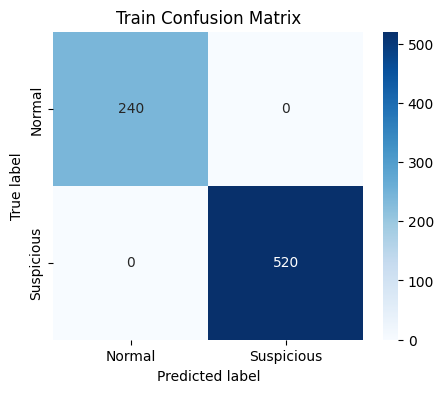

--- Test Results ---
Accuracy: 0.9474
F1 Score: 0.9620

Classification Report:

              precision    recall  f1-score   support

      Normal       0.94      0.89      0.91        18
  Suspicious       0.95      0.97      0.96        39

    accuracy                           0.95        57
   macro avg       0.95      0.93      0.94        57
weighted avg       0.95      0.95      0.95        57



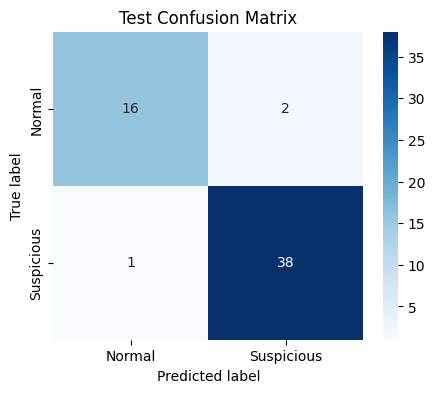

--- Validation Results ---
Accuracy: 0.9474
F1 Score: 0.9626

Classification Report:

              precision    recall  f1-score   support

      Normal       0.97      0.86      0.91        42
  Suspicious       0.94      0.99      0.96        91

    accuracy                           0.95       133
   macro avg       0.96      0.92      0.94       133
weighted avg       0.95      0.95      0.95       133



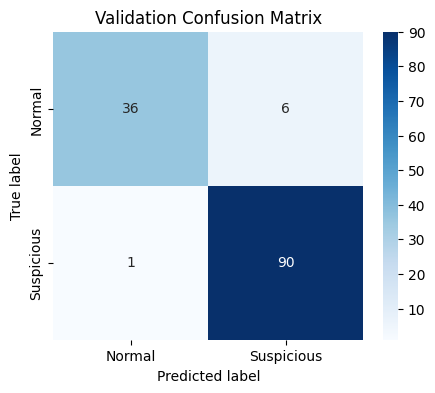

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Make predictions on a dataset
def evaluate_model(X, y_true, split_name="Test"):
    y_pred = clf.predict(X)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)

    # F1 Score (binary)
    f1 = f1_score(y_true, y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- {split_name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=encoder.classes_))

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(f"{split_name} Confusion Matrix")
    plt.show()

# Step 2: Evaluate on train, test, and validation
evaluate_model(X_train, y_train_enc, "Train")
evaluate_model(X_test, y_test_enc, "Test")
evaluate_model(X_valid, y_valid_enc, "Validation")

In [ ]:
# Define your normal classes
normal_classes = ["Normal", "Walking", "Meet", "Sitting", "Clapping", "Standing"]

# Function to map folder to label
def get_label(folder_name):
    return "Normal" if folder_name in normal_classes else "Suspicious"

# Function to get all classes under each label
def list_classes_by_label(dataset_dir):
    normal_list = []
    suspicious_list = []
    for cls in os.listdir(dataset_dir):
        cls_path = os.path.join(dataset_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        label = get_label(cls)
        if label == "Normal":
            normal_list.append(cls)
        else:
            suspicious_list.append(cls)
    return normal_list, suspicious_list

# Example: check for train split
train_normal, train_suspicious = list_classes_by_label(TRAIN_DIR)

print("Normal classes in Train:", train_normal)
print("Suspicious classes in Train:", train_suspicious)


Normal classes in Train: ['Sitting', 'Standing', 'Meet', 'Walking', 'Normal', 'Clapping']
Suspicious classes in Train: ['Vandalism', 'RoadAccidents', 'Assault', 'Abuse', 'Arrest', 'Robbery', 'Explosion', 'Fighting', 'Shooting', 'Stealing', 'Shoplifting', 'Burglary', 'Arson']


Prediction for video: Suspicious


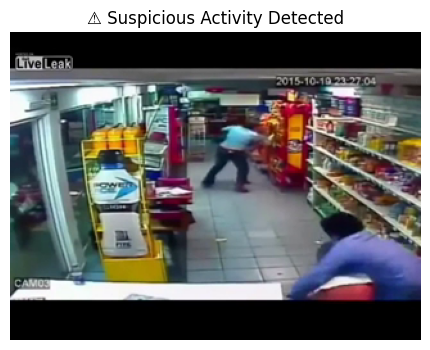

In [ ]:
import cv2
import matplotlib.pyplot as plt

def show_suspicious_frame(video_path):
    """
    Predicts if a video is Suspicious. If yes, displays one representative frame.
    """
    label = predict_video(video_path)
    print(f"Prediction for video: {label}")

    if label == "Suspicious":
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        mid_frame = total_frames // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame)
        ret, frame = cap.read()
        cap.release()

        if not ret:
            print("⚠️ Could not read frame from video.")
            return

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,4))
        plt.imshow(frame_rgb)
        plt.axis("off")
        plt.title("⚠️ Suspicious Activity Detected")
        plt.show()
    else:
        print("✅ This video was classified as Normal.")

# Example usage
test_video_path = os.path.join(TEST_DIR, "Fighting", os.listdir(os.path.join(TEST_DIR, "Fighting"))[0])
show_suspicious_frame(test_video_path)

In [ ]:
# ✅ Step 1: Install dependencies
!pip install transformers torch torchvision tqdm scikit-learn --quiet

# ✅ Step 2: Import libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel, ViTFeatureExtractor
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import numpy as np
import cv2

# ✅ Step 3: Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ✅ Step 4: Define data augmentation and preprocessing
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor()
])

# ✅ Step 5: Dataset loader for videos
class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.normal_classes = ["Normal", "Walking", "Meet", "Sitting", "Clapping", "Standing"]

        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            label = 0 if cls in self.normal_classes else 1  # 0 = Normal, 1 = Suspicious
            for video in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, video), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        cap = cv2.VideoCapture(path)
        frames = []
        for _ in range(8):  # sample 8 frames
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (224, 224))
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()
        if len(frames) == 0:
            frames = [torch.zeros(3, 224, 224)]
        video_tensor = torch.stack(frames).mean(dim=0)  # average frames
        return video_tensor, label

# ✅ Step 6: Load datasets
TRAIN_DIR = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/train"
TEST_DIR = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/test"
VALID_DIR = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/valid"

train_dataset = VideoDataset(TRAIN_DIR, transform)
test_dataset  = VideoDataset(TEST_DIR, transform)
valid_dataset = VideoDataset(VALID_DIR, transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

# ✅ Step 7: Define model (fine-tuned ViT)
class ViTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        self.fc = nn.Linear(768, 2)

    def forward(self, x):
        outputs = self.vit(x)
        cls_token = outputs.last_hidden_state[:, 0]
        out = self.fc(cls_token)
        return out

model = ViTClassifier().to(device)

# ✅ Step 8: Train setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.3)
best_val_acc = 0

# ✅ Step 9: Training loop with early stopping
for epoch in range(5):  # increase if needed
    model.train()
    total, correct = 0, 0
    running_loss = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

    train_acc = correct / total
    print(f"\nTrain Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_acc:.4f}")

    # Validation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = np.mean(np.array(y_true) == np.array(y_pred))
    scheduler.step(1 - val_acc)
    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_vit_model.pth")
        print("✅ Model saved!")

# ✅ Step 10: Testing & Evaluation
model.load_state_dict(torch.load("best_vit_model.pth"))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n--- Test Results ---")
print(classification_report(y_true, y_pred, target_names=["Normal", "Suspicious"]))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Using device: cpu


/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1 Training: 100%|██████████| 95/95 [23:14<00:00, 14.68s/it]



Train Loss: 0.3110, Train Accuracy: 0.8750
Validation Accuracy: 0.9474
✅ Model saved!


Epoch 2 Training: 100%|██████████| 95/95 [22:54<00:00, 14.47s/it]



Train Loss: 0.1634, Train Accuracy: 0.9408
Validation Accuracy: 0.9398


...


Train Loss: 0.1509, Train Accuracy: 0.9408
Validation Accuracy: 0.9323


Epoch 4 Training: 100%|██████████| 95/95 [22:43<00:00, 14.35s/it]



Train Loss: 0.1072, Train Accuracy: 0.9579
Validation Accuracy: 0.9549
✅ Model saved!


Epoch 5 Training: 100%|██████████| 95/95 [22:43<00:00, 14.35s/it]



Train Loss: 0.1023, Train Accuracy: 0.9539
Validation Accuracy: 0.9173

--- Test Results ---
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94        18
  Suspicious       0.95      1.00      0.97        39

    accuracy                           0.96        57
   macro avg       0.98      0.94      0.96        57
weighted avg       0.97      0.96      0.96        57

Confusion Matrix:
 [[16  2]
 [ 0 39]]


In [ ]:
# ✅ Step: Overall Validation Accuracy & Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

model.load_state_dict(torch.load("best_vit_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ✅ Calculate metrics
val_acc = accuracy_score(y_true, y_pred)
val_precision = precision_score(y_true, y_pred)
val_recall = recall_score(y_true, y_pred)
val_f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

# ✅ Display results
print("\n--- Overall Validation Metrics ---")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Precision            : {val_precision:.4f}")
print(f"Recall               : {val_recall:.4f}")
print(f"F1 Score             : {val_f1:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nDetailed Report:\n", classification_report(y_true, y_pred, target_names=["Normal", "Suspicious"]))



--- Overall Validation Metrics ---
Validation Accuracy : 93.98%
Precision            : 0.9192
Recall               : 1.0000
F1 Score             : 0.9579

Confusion Matrix:
 [[34  8]
 [ 0 91]]

Detailed Report:
               precision    recall  f1-score   support

      Normal       1.00      0.81      0.89        42
  Suspicious       0.92      1.00      0.96        91

    accuracy                           0.94       133
   macro avg       0.96      0.90      0.93       133
weighted avg       0.94      0.94      0.94       133



In [ ]:
# ✅ Step 1: Install dependencies
!pip install transformers torch torchvision tqdm scikit-learn accelerate --quiet

# ✅ Step 2: Import libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel, ViTFeatureExtractor, get_cosine_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import numpy as np
import cv2

# ✅ Step 3: Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ✅ Step 4: Preprocessing & Augmentations
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor()
])

# ✅ Step 5: Video dataset loader
class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.normal_classes = ["Normal", "Walking", "Meet", "Sitting", "Clapping", "Standing"]

        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            label = 0 if cls in self.normal_classes else 1  # 0=Normal, 1=Suspicious
            for video in os.listdir(cls_path):
                if video.endswith(".mp4"):
                    self.samples.append((os.path.join(cls_path, video), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        cap = cv2.VideoCapture(path)
        frames = []
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        # Sample 8 evenly spaced frames
        for i in np.linspace(0, total - 1, 8, dtype=int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()
        if len(frames) == 0:
            frames = [torch.zeros(3, 224, 224)]
        video_tensor = torch.stack(frames).mean(dim=0)
        return video_tensor, label

# ✅ Step 6: Dataset paths
TRAIN_DIR = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/train"
VALID_DIR = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/valid"
TEST_DIR  = "/root/.cache/kagglehub/datasets/daudshah/video-dataset/versions/1/balanced_dataset/test"

train_loader = DataLoader(VideoDataset(TRAIN_DIR, transform), batch_size=8, shuffle=True, num_workers=2)
valid_loader = DataLoader(VideoDataset(VALID_DIR, transform), batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(VideoDataset(TEST_DIR, transform), batch_size=8, shuffle=False, num_workers=2)

# ✅ Step 7: ViT model with frozen backbone
class ViTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False  # freeze layers
        for param in self.vit.encoder.layer[-4:].parameters():
            param.requires_grad = True  # fine-tune last 4 layers
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(768, 2)

    def forward(self, x):
        outputs = self.vit(x)
        cls_token = outputs.last_hidden_state[:, 0]
        x = self.dropout(cls_token)
        out = self.fc(x)
        return out

model = ViTClassifier().to(device)

# ✅ Step 8: Optimizer, Scheduler, Loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
num_training_steps = len(train_loader) * 8  # 8 epochs
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=200, num_training_steps=num_training_steps)

scaler = torch.cuda.amp.GradScaler()  # mixed precision
best_val_acc = 0

# ✅ Step 9: Training Loop
for epoch in range(8):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    train_acc = correct / total
    print(f"\nEpoch {epoch+1}: Train Loss={total_loss/len(train_loader):.4f}, Train Acc={train_acc*100:.2f}%")

    # Validation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"Validation Accuracy: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_vit_97.pth")
        print("✅ Best model saved!")

# ✅ Step 10: Testing
model.load_state_dict(torch.load("best_vit_97.pth"))
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n--- Test Results ---")
print(classification_report(y_true, y_pred, target_names=["Normal", "Suspicious"]))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))




Using device: cpu


/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2463120958.py:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # mixed precision
/usr/local/lib/python3.12/dist-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Epoch 1 Training:   0%|          | 0/95 [00:00<?, ?it/s]


Epoch 1: Train Loss=0.6147, Train Acc=65.92%


Validation Accuracy: 85.71%
✅ Best model saved!


Epoch 2 Training: 100%|██████████| 95/95 [23:20<00:00, 14.74s/it]


...


Epoch 7: Train Loss=0.1022, Train Acc=96.18%


Validation Accuracy: 93.98%


Epoch 8 Training: 100%|██████████| 95/95 [23:15<00:00, 14.69s/it]


Epoch 8: Train Loss=0.0863, Train Acc=96.84%


Validation Accuracy: 92.48%

--- Test Results ---
              precision    recall  f1-score   support

      Normal       0.94      0.89      0.91        18
  Suspicious       0.95      0.97      0.96        39

    accuracy                           0.95        57
   macro avg       0.95      0.93      0.94        57
weighted avg       0.95      0.95      0.95        57

Confusion Matrix:
 [[16  2]
 [ 1 38]]
